# Movie Recommendation System
## Data Mining Project 2

**Dataset:** MovieLens  `movies.csv` (62 k titles)`ratings.csv` (25M ratings)

---

### Techniques Covered

| # | Technique | Section |
|---|-----------|--------|
| 1 | Data Loading & Integration | 1 |
| 2 | Data Cleaning | 2 |
| 3 | Histogram Analysis | 3 |
| 4 | Sampling (Random + Stratified) | 4 |
| 5 | Data Transformation (log / sqrt) | 5 |
| 6 | Normalization (Min-Max + Z-Score) | 5 |
| 7 | Data Discretization | 6 |
| 8 | PCA  Dimensionality Reduction | 7 |
| 9 | Attribute Subset Selection | 8 |
| 10 | Data Compression (SVD) | 9 |
| 11 | Linear / Multiple / Log-Linear Regression | 10 |
| 12 | Clustering (K-Means) | 11 |
| 13 | Content-Based Filtering | 12 |
| 14 | Collaborative Filtering (SVD) | 13 |
| 15 | Hybrid Recommender | 14 |
| 16 | Decision Tree Classification | 15 |
| 17 | Export Results | 16 |


In [238]:
# Imports
import os, difflib, warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

# Dimensionality reduction & compression
from sklearn.decomposition import PCA, TruncatedSVD

# Preprocessing & feature selection
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit

# Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity

# Metrics
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    mean_squared_error, r2_score
)
from scipy.sparse import csr_matrix

warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11
print('Libraries loaded.')

Libraries loaded.


In [239]:
# Create output folder for images and results
import os
OUTPUT_DIR = 'output'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'Output directory: {OUTPUT_DIR}')


Output directory: output


---
## Section 1 Data Loading & Integration

**Data Integration** combines information from multiple sources into one unified view. Here we load two separate CSV files movie metadata and user ratings and merge them to create a richer dataset for analysis.

- `movies.csv` movie catalogue (title, genres)
- `ratings.csv` user interactions (userId, movieId, rating, timestamp)

In [240]:
# Data Loading
# Load movies and a sample of ratings (the dataset is huge, so we'll sample it).
# Taking 500k ratings to keep things manageable and prevent Jupyter from crashing
MOVIES_PATH  = 'movies.csv'
RATINGS_PATH = 'ratings.csv'
SAMPLE_SIZE  = 500_000

movies  = pd.read_csv(MOVIES_PATH)
ratings = pd.read_csv(RATINGS_PATH, nrows=SAMPLE_SIZE)

print(f'movies  : {movies.shape[0]:>7,} rows | cols: {list(movies.columns)}')
print(f'ratings : {ratings.shape[0]:>7,} rows | cols: {list(ratings.columns)}')
print()
display(movies.head(3))
display(ratings.head(3))

movies  :  62,423 rows | cols: ['movieId', 'title', 'genres']
ratings : 500,000 rows | cols: ['userId', 'movieId', 'rating', 'timestamp']



,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance


,userId,movieId,rating,timestamp
0,1,296,5.0,1147880044
1,1,306,3.5,1147868817
2,1,307,5.0,1147868828


In [241]:
# Data Integration
# So we need to combine the two datasets. Let's aggregate rating stats per movie
# and merge it onto the movies table. This way we have everything in one place.
movie_rating_agg = (
    ratings.groupby('movieId')
    .agg(
        num_ratings = ('rating', 'count'),
        avg_rating  = ('rating', 'mean'),
        std_rating  = ('rating', 'std'),
        min_rating  = ('rating', 'min'),
        max_rating  = ('rating', 'max'),
    )
    .reset_index()
)

# Left join keeps all movies, even ones that didn't get any ratings in our sample
movies_int = movies.merge(movie_rating_agg, on='movieId', how='left')
print(f'Integrated dataset shape: {movies_int.shape}')
display(movies_int.head(5))

Integrated dataset shape: (62423, 8)


,movieId,title,genres,num_ratings,avg_rating,std_rating,min_rating,max_rating
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1167.0,3.901028,0.914585,0.5,5.0
1,2,Jumanji (1995),Adventure|Children|Fantasy,475.0,3.312632,0.935498,0.5,5.0
2,3,Grumpier Old Men (1995),Comedy|Romance,281.0,3.144128,1.026285,0.5,5.0
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,37.0,2.932432,0.883193,1.0,4.5
4,5,Father of the Bride Part II (1995),Comedy,249.0,3.156627,0.997763,0.5,5.0


---
## Section 2 Data Cleaning

**Data Cleaning** identifies and corrects errors or inconsistencies in the raw data. Common issues include missing values, duplicates, out-of-range values, and inconsistent formatting. Clean data is essential for reliable results from any downstream analysis.

In [242]:
# Inspect for quality issues
print('Missing Values (movies_int)')
print(movies_int.isnull().sum().to_string())
print()
print(f'Duplicate movieIds : {movies_int["movieId"].duplicated().sum()}')
print(f'Duplicate titles   : {movies_int["title"].duplicated().sum()}')
print()
print('=== Movies with no genres ===')
print(f'Count: {(movies_int["genres"] == "(no genres listed)").sum()}')
print()
print('=== Ratings out of valid range (0.5 5.0) ===')
bad = ~ratings['rating'].between(0.5, 5.0)
print(f'Out-of-range: {bad.sum()}')
print()
print('Rating value distribution')
print(ratings['rating'].value_counts().sort_index().to_string())

Missing Values (movies_int)
movieId            0
title              0
genres             0
num_ratings    44957
avg_rating     44957
std_rating     50615
min_rating     44957
max_rating     44957

Duplicate movieIds : 0
Duplicate titles   : 98

=== Movies with no genres ===
Count: 5062

=== Ratings out of valid range (0.5 5.0) ===
Out-of-range: 0

Rating value distribution
rating
0.5      7569
1.0     14443
1.5      8484
2.0     32295
2.5     24986
3.0     97144
3.5     62535
4.0    134700
4.5     43600
5.0     74244


In [243]:
# Need to clean up the data before using it

# 1. Remove duplicate movies (keep the first one)
movies_clean = movies_int.drop_duplicates(subset='movieId', keep='first').copy()

# 2. Fix the weird "(no genres listed)" label
movies_clean['genres'] = movies_clean['genres'].replace('(no genres listed)', 'Unknown')

# 3. Fill in missing rating stats with 0 (movies nobody rated)
for col in ['num_ratings', 'avg_rating', 'std_rating', 'min_rating', 'max_rating']:
    movies_clean[col] = movies_clean[col].fillna(0)

# 4. Extract the year from the title (e.g., 'Toy Story (1995)' -> 1995)
movies_clean['year'] = (
    movies_clean['title']
    .str.extract(r'\((\d{4})\)')
    .squeeze()
    .astype(float)
)

# 5. Filter out any weird ratings outside 0.5-5.0 range
ratings_clean = ratings[ratings['rating'].between(0.5, 5.0)].copy()

print('After cleaning:')
print(f'  Movies (clean)  : {len(movies_clean):,}')
print(f'  Ratings (clean) : {len(ratings_clean):,}')
print(f'  Missing year    : {movies_clean["year"].isnull().sum()}')
display(movies_clean[['movieId','title','year','genres','num_ratings','avg_rating']].head(5))

After cleaning:
  Movies (clean)  : 62,423
  Ratings (clean) : 500,000
  Missing year    : 410


,movieId,title,year,genres,num_ratings,avg_rating
0,1,Toy Story (1995),1995.0,Adventure|Animation|Children|Comedy|Fantasy,1167.0,3.901028
1,2,Jumanji (1995),1995.0,Adventure|Children|Fantasy,475.0,3.312632
2,3,Grumpier Old Men (1995),1995.0,Comedy|Romance,281.0,3.144128
3,4,Waiting to Exhale (1995),1995.0,Comedy|Drama|Romance,37.0,2.932432
4,5,Father of the Bride Part II (1995),1995.0,Comedy,249.0,3.156627


---
## Section 3 Exploratory Data Analysis & Histogram Analysis

**Histogram Analysis** visualises the frequency distribution of numeric variables. It reveals shape (skewed vs symmetric), spread, outliers, and natural groupings in the data. This step guides later decisions about transformations, binning, and outlier handling.

In [244]:
# Descriptive Statistics
print('=== Key Statistics ===')
stats_cols = ['num_ratings', 'avg_rating', 'std_rating', 'year']
rated = movies_clean[movies_clean['num_ratings'] > 0]
print(rated[stats_cols].describe().round(3).to_string())
print()
print(f'Unique genres (combinations) : {movies_clean["genres"].nunique():,}')
print(f'Unique users in sample       : {ratings_clean["userId"].nunique():,}')
print(f'Unique movies in ratings     : {ratings_clean["movieId"].nunique():,}')

=== Key Statistics ===
       num_ratings  avg_rating  std_rating       year
count    17466.000   17466.000   17466.000  17429.000
mean        28.627       3.276       0.606   1994.393
std         89.977       0.807       0.539     21.334
min          1.000       0.500       0.000   1896.000
25%          1.000       2.944       0.000   1986.000
50%          3.000       3.417       0.707   2001.000
75%         15.000       3.833       1.000   2010.000
max       1701.000       5.000       3.182   2019.000

Unique genres (combinations) : 1,639
Unique users in sample       : 3,445
Unique movies in ratings     : 17,466


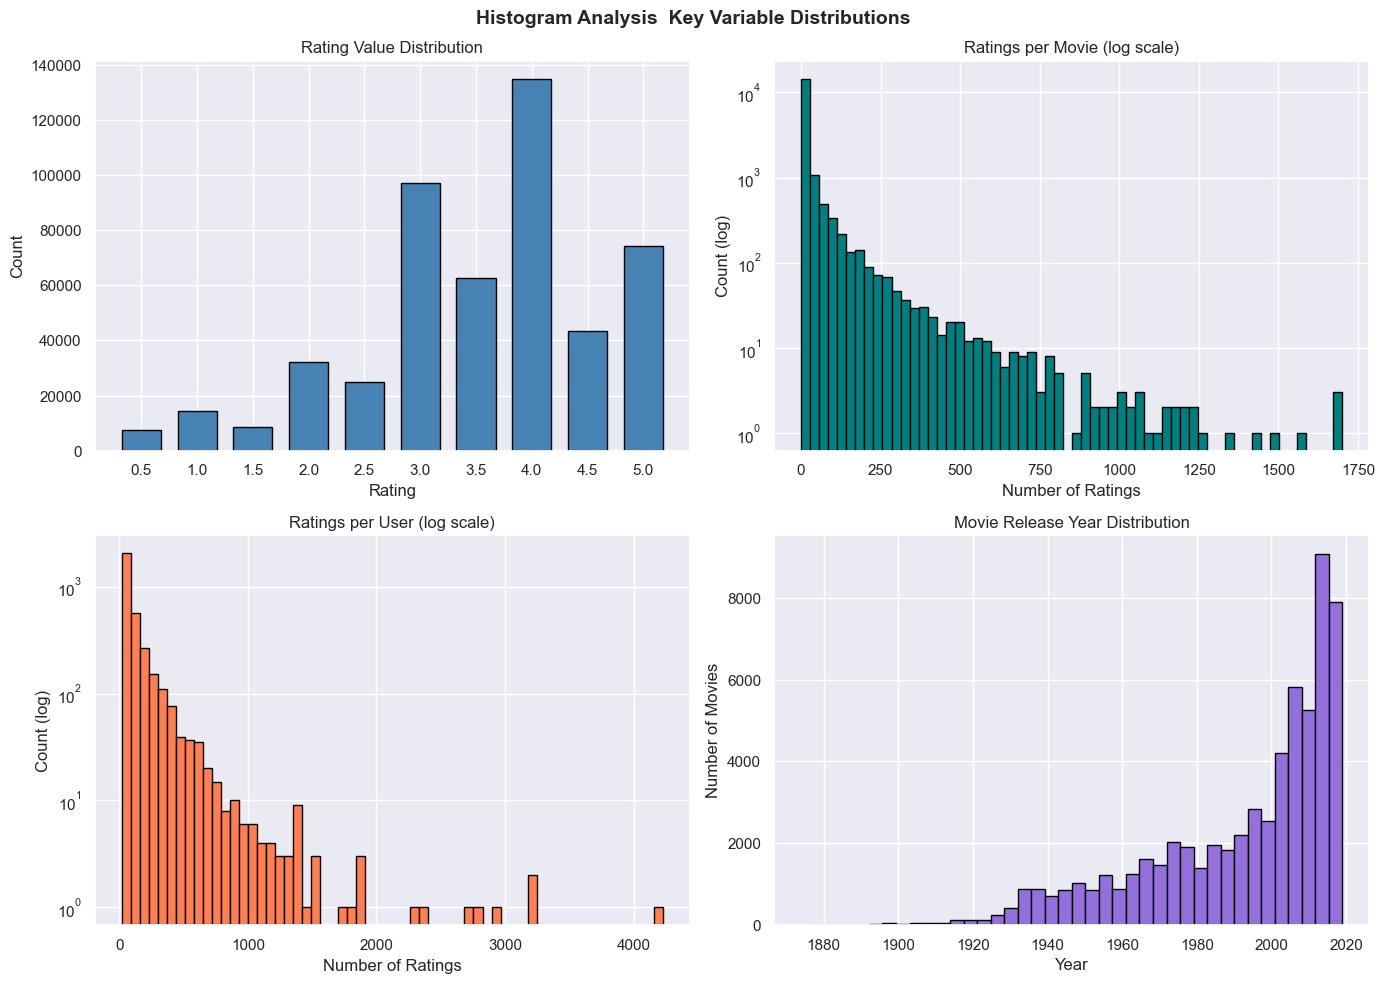

In [245]:
# Make 4 histograms to visualize the distributions
# Using log scale on some because the data is really skewed
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: How many of each rating value?
rv = ratings_clean['rating'].value_counts().sort_index()
axes[0,0].bar(rv.index, rv.values, color='steelblue', edgecolor='black', width=0.35)
axes[0,0].set_title('Rating Value Distribution')
axes[0,0].set_xlabel('Rating'); axes[0,0].set_ylabel('Count')
axes[0,0].set_xticks(rv.index)

# Panel 2: How many ratings per movie (log scale - very skewed)
mrc = ratings_clean.groupby('movieId').size()
axes[0,1].hist(mrc, bins=60, color='teal', edgecolor='black', log=True)
axes[0,1].set_title('Ratings per Movie (log scale)')
axes[0,1].set_xlabel('Number of Ratings'); axes[0,1].set_ylabel('Count (log)')

# Panel 3: How many ratings per user (also log scale)
urc = ratings_clean.groupby('userId').size()
axes[1,0].hist(urc, bins=60, color='coral', edgecolor='black', log=True)
axes[1,0].set_title('Ratings per User (log scale)')
axes[1,0].set_xlabel('Number of Ratings'); axes[1,0].set_ylabel('Count (log)')

# Panel 4: Movie release years
yd = movies_clean['year'].dropna()
axes[1,1].hist(yd, bins=40, color='mediumpurple', edgecolor='black')
axes[1,1].set_title('Movie Release Year Distribution')
axes[1,1].set_xlabel('Year'); axes[1,1].set_ylabel('Number of Movies')

plt.suptitle('Histogram Analysis  Key Variable Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/01_histogram_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

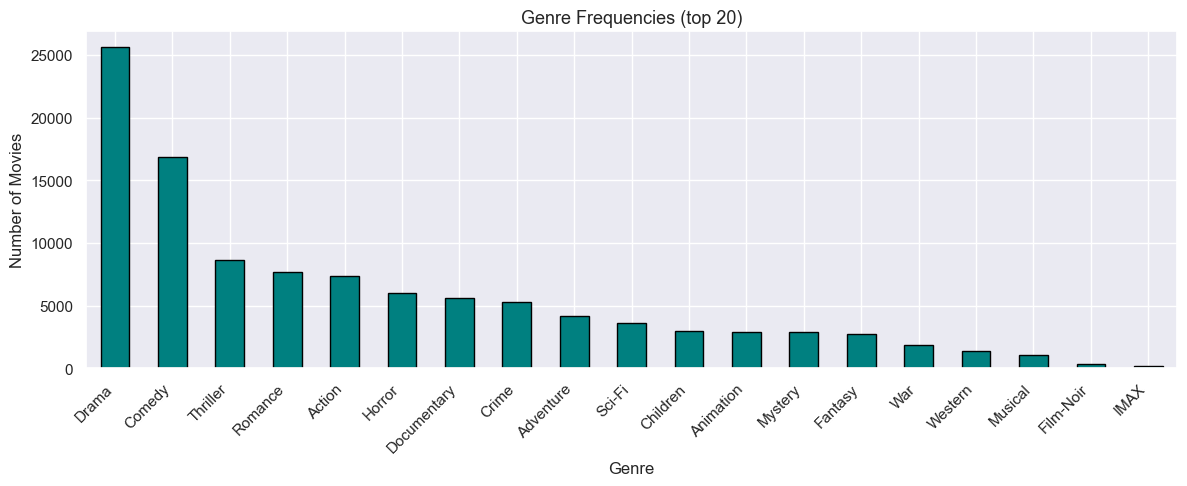

Total unique genres: 19


In [246]:
# Genre analysis
# Split up the pipe-separated genre strings into individual genres so we can count them
genre_series = (
    movies_clean['genres']
    .str.split('|').explode().str.strip()
)
genre_counts = genre_series[~genre_series.isin(['Unknown',''])].value_counts()

plt.figure(figsize=(12, 5))
genre_counts.head(20).plot(kind='bar', color='teal', edgecolor='black')
plt.title('Genre Frequencies (top 20)', fontsize=13)
plt.xlabel('Genre'); plt.ylabel('Number of Movies')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/02_genre_frequencies.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Total unique genres: {len(genre_counts)}')

---
## Section 4 Sampling

**Sampling** selects a representative subset of data when working with the full dataset is computationally expensive. Two strategies are compared:

- **Random Sampling**  each record has equal probability of selection. Simple but may under-represent rare groups.
- **Stratified Sampling** samples proportionally from each stratum (here: each rating value). Guarantees the sample preserves the original class distribution.

Full dataset          : 500,000 rows
Random sample (10 %)  : 50,000 rows
Mean rating  full    : 3.5491
Mean rating  random  : 3.5523

Stratified sample     : 50,000 rows
Mean rating strat   : 3.5491


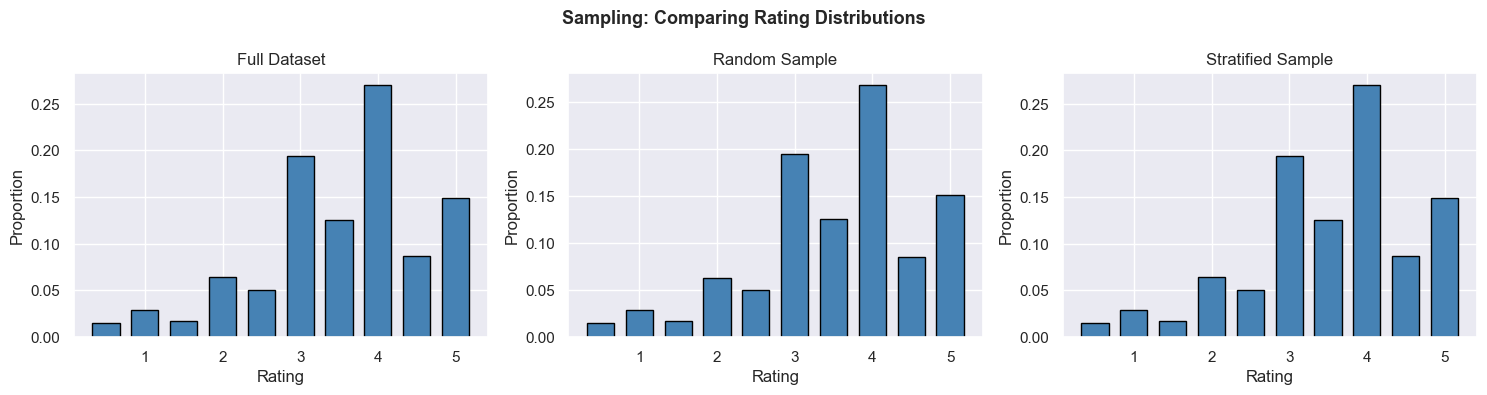

In [247]:
# 4.1 Random Sampling
# Sample 10% of the ratings randomly
RANDOM_FRAC  = 0.10
random_sample = ratings_clean.sample(frac=RANDOM_FRAC, random_state=42)

print(f'Full dataset          : {len(ratings_clean):,} rows')
print(f'Random sample (10 %)  : {len(random_sample):,} rows')
print(f'Mean rating  full    : {ratings_clean["rating"].mean():.4f}')
print(f'Mean rating  random  : {random_sample["rating"].mean():.4f}')
print()

# 4.2 Stratified Sampling
# Sample from each rating category proportionally to keep the distribution balanced
ratings_clean['rating_bin'] = (ratings_clean['rating'] * 2).astype(int)

sss = StratifiedShuffleSplit(n_splits=1, test_size=RANDOM_FRAC, random_state=42)
for _, idx in sss.split(ratings_clean, ratings_clean['rating_bin']):
    stratified_sample = ratings_clean.iloc[idx]

print(f'Stratified sample     : {len(stratified_sample):,} rows')
print(f'Mean rating strat   : {stratified_sample["rating"].mean():.4f}')

# Compare the two approaches side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, df, lbl in zip(axes,
                        [ratings_clean, random_sample, stratified_sample],
                        ['Full Dataset', 'Random Sample', 'Stratified Sample']):
    vc = df['rating'].value_counts().sort_index()
    ax.bar(vc.index, vc.values / len(df), color='steelblue', edgecolor='black', width=0.35)
    ax.set_title(lbl); ax.set_xlabel('Rating'); ax.set_ylabel('Proportion')
plt.suptitle('Sampling: Comparing Rating Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/03_sampling_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

---
## Section 5  Data Transformation & Normalization

**Data Transformation** converts raw values into a form better suited for analysis. Log and square-root transforms reduce skewness in heavy-tailed distributions.

**Normalization** rescales features to a common range so no single feature dominates distance or gradient calculations:
- **Min-Max**: scales values to [0, 1]
- **Z-Score (Standard)**: shifts to mean = 0, std = 1

In [248]:
# Build numeric feature table for movies with key stats and release year.
movie_features = movies_clean[movies_clean['num_ratings'] > 0][
    ['movieId','title','num_ratings','avg_rating','year']
].dropna().copy()

print(f'Movies with ratings in sample: {len(movie_features):,}')
print(movie_features[['num_ratings','avg_rating','year']].describe().round(2).to_string())

Movies with ratings in sample: 17,429
       num_ratings  avg_rating      year
count     17429.00    17429.00  17429.00
mean         28.68        3.28   1994.39
std          90.07        0.81     21.33
min           1.00        0.50   1896.00
25%           1.00        2.94   1986.00
50%           3.00        3.42   2001.00
75%          15.00        3.83   2010.00
max        1701.00        5.00   2019.00


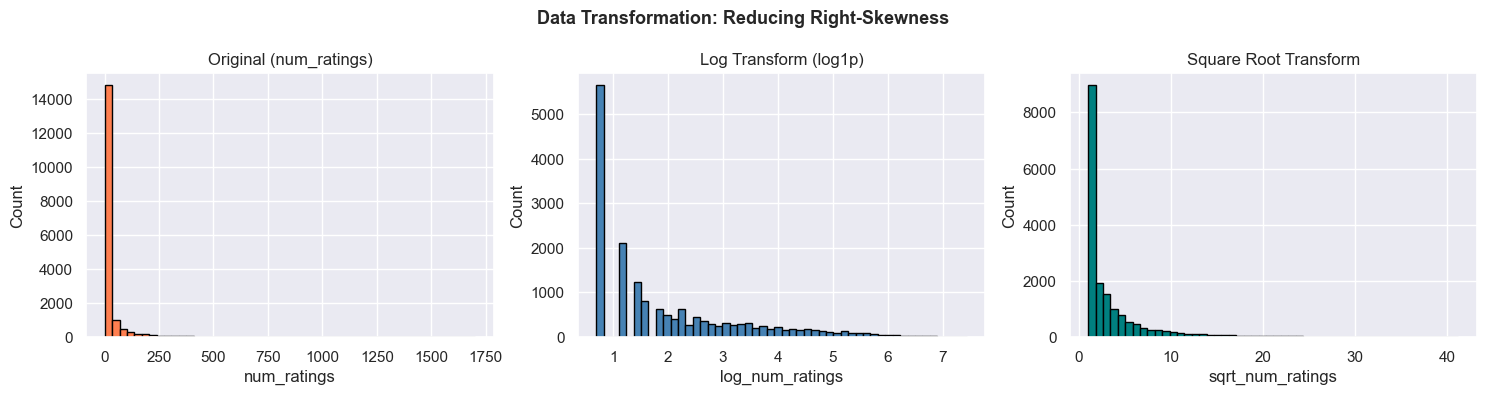

Skewness  original       : 7.4982
Skewness   log transform  : 1.1514
Skewness   sqrt transform : 3.1496


In [249]:
# 5.1 Data Transformation
# The number of ratings is really skewed (popular movies get many more ratings)
# Try log and sqrt transforms to make the distribution less skewed
movie_features['log_num_ratings']  = np.log1p(movie_features['num_ratings'])
movie_features['sqrt_num_ratings'] = np.sqrt(movie_features['num_ratings'])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, clr, ttl in zip(axes,
    ['num_ratings','log_num_ratings','sqrt_num_ratings'],
    ['coral','steelblue','teal'],
    ['Original (num_ratings)','Log Transform (log1p)','Square Root Transform']):
    ax.hist(movie_features[col], bins=50, color=clr, edgecolor='black')
    ax.set_title(ttl); ax.set_xlabel(col); ax.set_ylabel('Count')
plt.suptitle('Data Transformation: Reducing Right-Skewness', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/04_data_transformation.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'Skewness  original       : {movie_features["num_ratings"].skew():.4f}')
print(f'Skewness   log transform  : {movie_features["log_num_ratings"].skew():.4f}')
print(f'Skewness   sqrt transform : {movie_features["sqrt_num_ratings"].skew():.4f}')

In [250]:
# 5.2 Normalization
# Scale all features to the same range so one feature doesn't dominate
norm_cols = ['num_ratings','avg_rating','year','log_num_ratings']
mf = movie_features.dropna(subset=norm_cols).copy()

# Min-Max: squeeze everything into [0, 1]
mm = MinMaxScaler()
mf_minmax = mf.copy()
mf_minmax[norm_cols] = mm.fit_transform(mf[norm_cols])

# Z-Score: center at 0 with standard deviation of 1
zs = StandardScaler()
mf_zscore = mf.copy()
mf_zscore[norm_cols] = zs.fit_transform(mf[norm_cols])

print('Min-Max Normalization (all values in [0, 1]):')
print(mf_minmax[norm_cols].describe().round(4).to_string())
print()
print('Z-Score Normalization (mean 0, std 1):')  
print(mf_zscore[norm_cols].describe().round(4).to_string())

Min-Max Normalization (all values in [0, 1]):
       num_ratings  avg_rating        year  log_num_ratings
count   17429.0000  17429.0000  17429.0000       17429.0000
mean        0.0163      0.6169      0.7999           0.1886
std         0.0530      0.1792      0.1735           0.2112
min         0.0000      0.0000      0.0000           0.0000
25%         0.0000      0.5432      0.7317           0.0000
50%         0.0012      0.6481      0.8537           0.1027
75%         0.0082      0.7407      0.9268           0.3082
max         1.0000      1.0000      1.0000           1.0000

Z-Score Normalization (mean 0, std 1):
       num_ratings  avg_rating        year  log_num_ratings
count   17429.0000  17429.0000  17429.0000       17429.0000
mean       -0.0000      0.0000     -0.0000           0.0000
std         1.0000      1.0000      1.0000           1.0000
min        -0.3073     -3.4433     -4.6120          -0.8931
25%        -0.3073     -0.4113     -0.3934          -0.8931
50%        -0.

---
## Section 6  Data Discretization

**Data Discretization** converts continuous numeric values into discrete categories (bins). This reduces sensitivity to small measurement errors, enables categorical analysis, and can improve the interpretability of classification models.

- **Equal-Width Binning** divides the value range into bins of equal size
- **Equal-Frequency (Quantile) Binning**  each bin contains the same number of records

Rating Discretization (equal-width):
rating_category
Poor          87777
Average      159679
Good         134700
Excellent    117844

Movie Popularity (quantile bins) — movies with >= 2 ratings:
popularity_rank
Niche          3325
Moderate       2653
Popular        2937
Blockbuster    2877


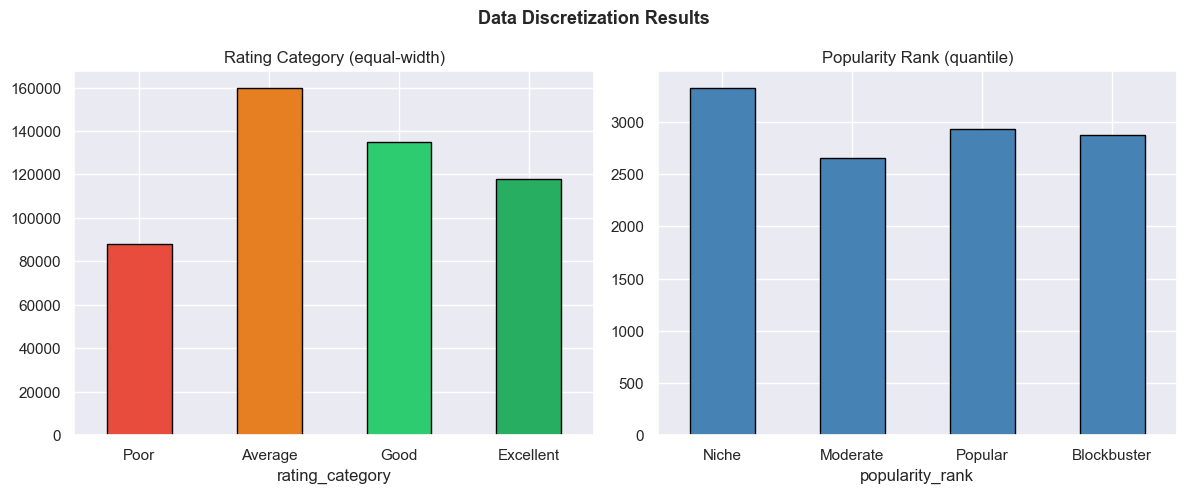

In [251]:
# 6.1 Equal-Width Binning
# Create rating categories by splitting the range into equal-sized groups
BINS   = [0.0, 2.5, 3.5, 4.2, 5.0]
LABELS = ['Poor', 'Average', 'Good', 'Excellent']

ratings_clean['rating_category'] = pd.cut(
    ratings_clean['rating'],
    bins=BINS, labels=LABELS, include_lowest=True
)
print('Rating Discretization (equal-width):')
print(ratings_clean['rating_category'].value_counts().reindex(LABELS).to_string())
print()

# 6.2 Equal-Frequency (Quantile) Binning
# Split movies into 4 groups based on rating count
# Each group has roughly the same number of movies
mf_disc = movie_features[movie_features['num_ratings'] >= 2].copy()
mf_disc['popularity_rank'] = pd.qcut(
    mf_disc['num_ratings'], q=4,
    labels=['Niche', 'Moderate', 'Popular', 'Blockbuster'],
    duplicates='drop'
)
print('Movie Popularity (quantile bins) — movies with >= 2 ratings:')
print(mf_disc['popularity_rank'].value_counts().sort_index().to_string())

# Visualize both discretizations
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cat_c = ratings_clean['rating_category'].value_counts().reindex(LABELS)
cat_c.plot(kind='bar', ax=axes[0],
           color=['#e74c3c','#e67e22','#2ecc71','#27ae60'], edgecolor='black')
axes[0].set_title('Rating Category (equal-width)'); axes[0].tick_params(axis='x', rotation=0)

mf_disc['popularity_rank'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('Popularity Rank (quantile)'); axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Data Discretization Results', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/06_discretization_results.png', dpi=300, bbox_inches='tight')
plt.show()

---
## Section 7 PCA (Principal Component Analysis)

**PCA** is a linear dimensionality-reduction technique. It projects data onto a new coordinate system where each axis (principal component) captures the maximum remaining variance. Key benefits:

- Removes redundant / correlated features
- Enables 2D/3D visualisation of high-dimensional data
- Reduces computation for downstream algorithms

We apply PCA to the **genre one-hot matrix** (20+ dimensions â†’ fewer components).

In [252]:
# Create a one-hot matrix: rows = movies, columns = genres
# 1 if movie has that genre, 0 if it doesn't
genre_ohe = movies_clean['genres'].str.get_dummies(sep='|')
genre_ohe.columns = (
    genre_ohe.columns
    .str.replace('(no genres listed)', 'Unknown', regex=False)
    .str.replace(' ', '_', regex=False)
    .str.replace('-', '_', regex=False)
)
genre_ohe['movieId'] = movies_clean['movieId'].values

genre_feat_cols = [c for c in genre_ohe.columns if c != 'movieId']
X_genres = genre_ohe[genre_feat_cols].values.astype(np.float32)

print(f'Genre one-hot matrix : {X_genres.shape[0]:,} movies x {X_genres.shape[1]} genres')
print(f'Genres               : {genre_feat_cols}')

Genre one-hot matrix : 62,423 movies x 20 genres
Genres               : ['Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film_Noir', 'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci_Fi', 'Thriller', 'Unknown', 'War', 'Western']


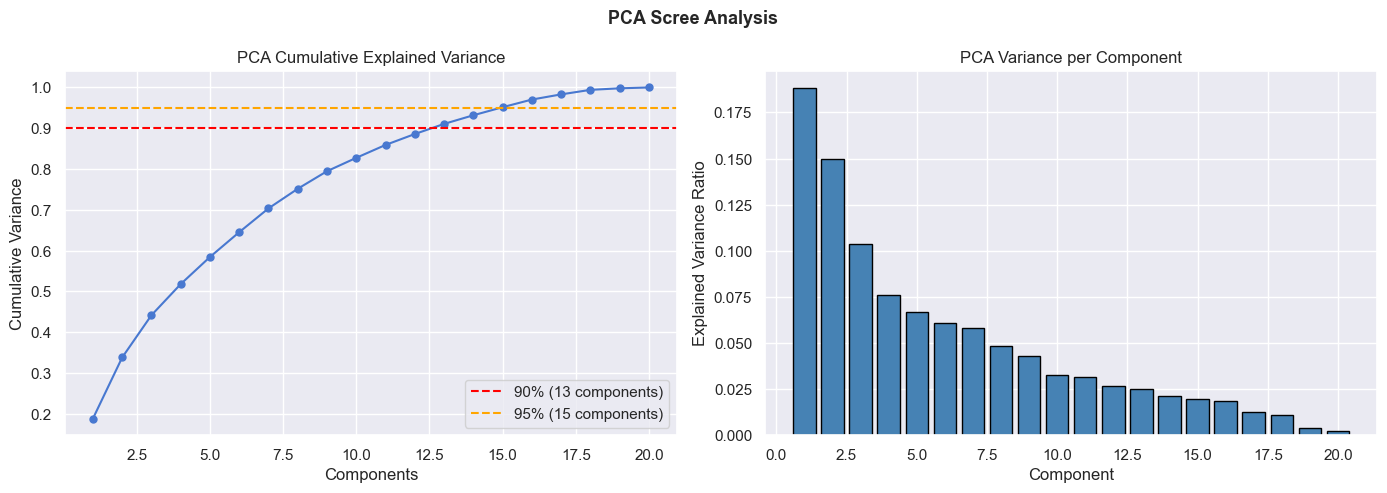

Original dimensions         : 20
Components for 90% variance : 13  (reduction: 35%)
Components for 95% variance : 15  (reduction: 25%)


In [253]:
# Run PCA to see how many components are needed to explain the variance
pca_full = PCA(random_state=42)
pca_full.fit(X_genres)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_90   = int(np.searchsorted(cumvar, 0.90)) + 1
n_95   = int(np.searchsorted(cumvar, 0.95)) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot showing cumulative variance
axes[0].plot(range(1, len(cumvar)+1), cumvar, 'bo-', ms=5)
axes[0].axhline(0.90, color='red',    ls='--', label=f'90% ({n_90} components)')
axes[0].axhline(0.95, color='orange', ls='--', label=f'95% ({n_95} components)')
axes[0].set_title('PCA Cumulative Explained Variance')
axes[0].set_xlabel('Components'); axes[0].set_ylabel('Cumulative Variance')
axes[0].legend()

# Individual component variance
axes[1].bar(range(1, X_genres.shape[1]+1), pca_full.explained_variance_ratio_,
            color='steelblue', edgecolor='black')
axes[1].set_title('PCA Variance per Component')
axes[1].set_xlabel('Component'); axes[1].set_ylabel('Explained Variance Ratio')

plt.suptitle('PCA Scree Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/07_pca_scree_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'Original dimensions         : {X_genres.shape[1]}')
print(f'Components for 90% variance : {n_90}  (reduction: {1-n_90/X_genres.shape[1]:.0%})')
print(f'Components for 95% variance : {n_95}  (reduction: {1-n_95/X_genres.shape[1]:.0%})')

PCA(5) explained variance: 0.5845


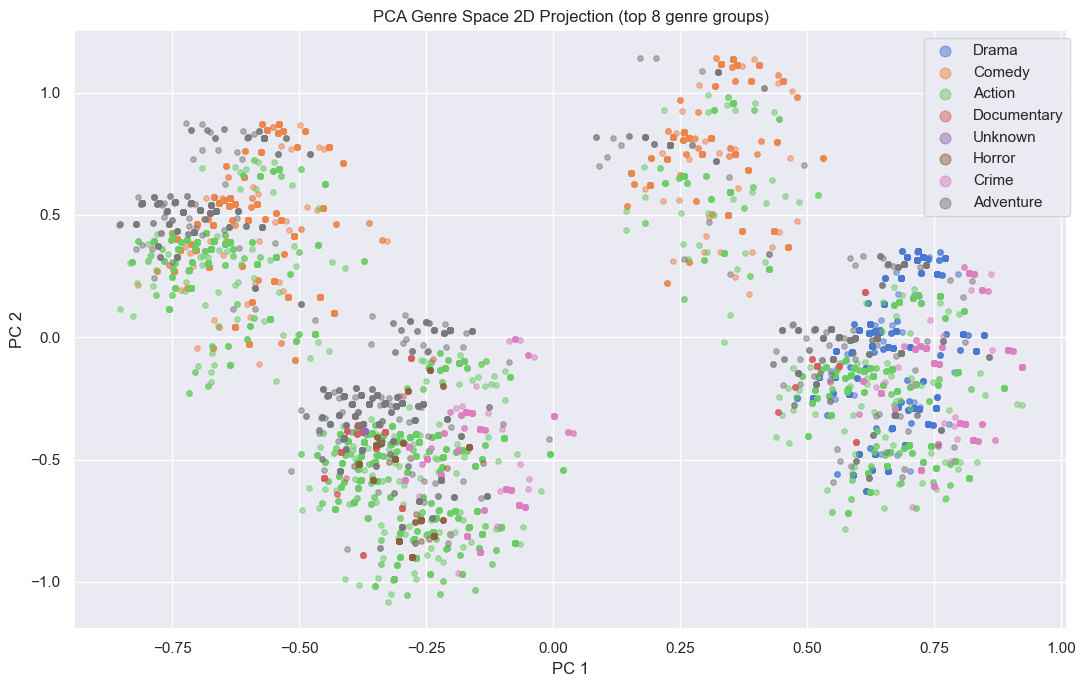

In [254]:
# Project the data to 2D using PCA for visualization
pca5 = PCA(n_components=5, random_state=42)
genre_pca5 = pca5.fit_transform(X_genres)
print(f'PCA(5) explained variance: {pca5.explained_variance_ratio_.sum():.4f}')

main_genre = movies_clean['genres'].str.split('|').str[0].str.strip()
main_genre = main_genre.replace({'(no genres listed)':'Unknown'})
top_genres = main_genre.value_counts().head(8).index
mask = main_genre.isin(top_genres)

plt.figure(figsize=(11, 7))
for g in top_genres:
    idx = (main_genre == g).values & mask.values
    plt.scatter(genre_pca5[idx, 0], genre_pca5[idx, 1], label=g, alpha=0.5, s=15)
plt.xlabel('PC 1'); plt.ylabel('PC 2')
plt.title('PCA Genre Space 2D Projection (top 8 genre groups)')
plt.legend(markerscale=2, bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/08_pca_genre_space_2d.png', dpi=300, bbox_inches='tight')
plt.show()

---
## Section 8 Attribute Subset Selection

**Attribute Subset Selection** reduces the feature space by retaining only the most informative attributes. Benefits: faster training, less overfitting, better interpretability.

Two filter-based methods are demonstrated:
- **Variance Threshold**  removes near-constant features (variance < threshold)
- **SelectKBest (F-score)**  ranks features by their univariate correlation with the target label

Feature matrix before selection: (50000, 20)

Variance Threshold (0.01):
  Before : 20 features
  After  : 18 features
  Removed: ['Film_Noir', 'Unknown']

SelectKBest top 10 (F-score):
  Drama                     F = 593.69
  Comedy                    F = 273.54
  Crime                     F = 172.25
  Horror                    F = 147.32
  War                       F = 144.80
  Action                    F = 110.94
  Mystery                   F = 48.95
  Sci_Fi                    F = 44.71
  Film_Noir                 F = 33.56
  Children                  F = 30.63


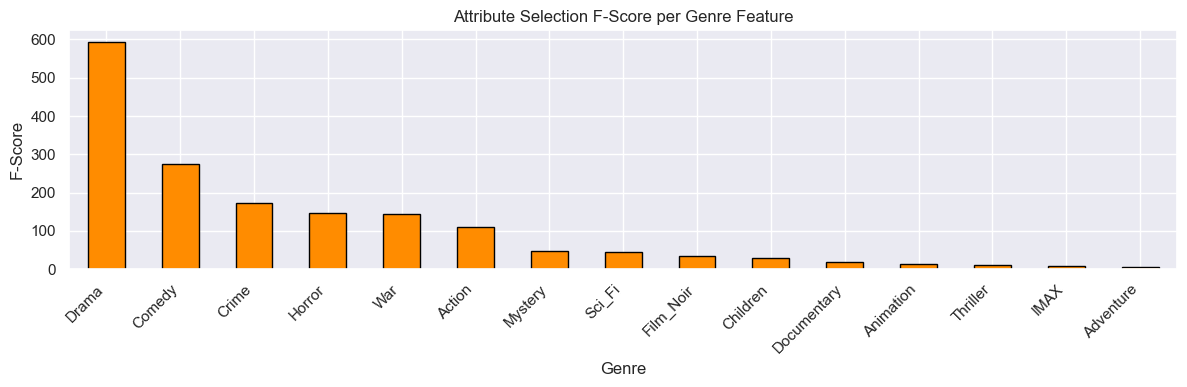

In [255]:
# Prepare data for classification and feature selection
# We want to predict if someone will like a movie (rating >= 4.0)
sel_sample = stratified_sample.merge(
    genre_ohe, on='movieId', how='left'
).dropna()
sel_sample['liked'] = (sel_sample['rating'] >= 4.0).astype(int)

X_feat = sel_sample[genre_feat_cols].values
y_feat = sel_sample['liked'].values
print(f'Feature matrix before selection: {X_feat.shape}')

# 8.1 Variance Threshold
# Remove genres with low variance (appear in less than 1% of movies)
vt = VarianceThreshold(threshold=0.01)
X_vt = vt.fit_transform(X_feat)
removed_vt = np.array(genre_feat_cols)[~vt.get_support()].tolist()
kept_vt    = np.array(genre_feat_cols)[vt.get_support()].tolist()

print(f'\nVariance Threshold (0.01):')
print(f'  Before : {X_feat.shape[1]} features')
print(f'  After  : {X_vt.shape[1]} features')
print(f'  Removed: {removed_vt}')

# 8.2 SelectKBest
# Find the best genres that predict whether someone will like a movie
kb = SelectKBest(score_func=f_classif, k=10)
kb.fit(X_feat, y_feat)
feat_scores = pd.Series(kb.scores_, index=genre_feat_cols).sort_values(ascending=False)

print(f'\nSelectKBest top 10 (F-score):')
for feat, score in feat_scores.head(10).items():
    print(f'  {feat:<25} F = {score:.2f}')

plt.figure(figsize=(12, 4))
feat_scores.head(15).plot(kind='bar', color='darkorange', edgecolor='black')
plt.title('Attribute Selection F-Score per Genre Feature')
plt.xlabel('Genre'); plt.ylabel('F-Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/08_attribute_selection.png', dpi=300, bbox_inches='tight')
plt.show()

---
## Section 9  Data Compression (Truncated SVD)

**Data Compression** reduces storage and computation by representing data in a lower-dimensional space. **Truncated SVD** keeps only the *k* largest singular values, discarding directions of low variance.

- The compression is **lossy**  some information is dropped
- The trade-off between compression ratio and reconstruction error guides choosing *k*
- In recommender systems, SVD latent factors capture abstract user/item preferences

SVD Compression Results:


,k,MSE,Explained Var,Ratio
0,2,0.05260,0.2957,2/20
1,5,0.03327,0.5551,5/20
2,10,0.01364,0.8135,10/20
3,15,0.00374,0.9489,15/20
4,19,0.00015,0.9979,19/20


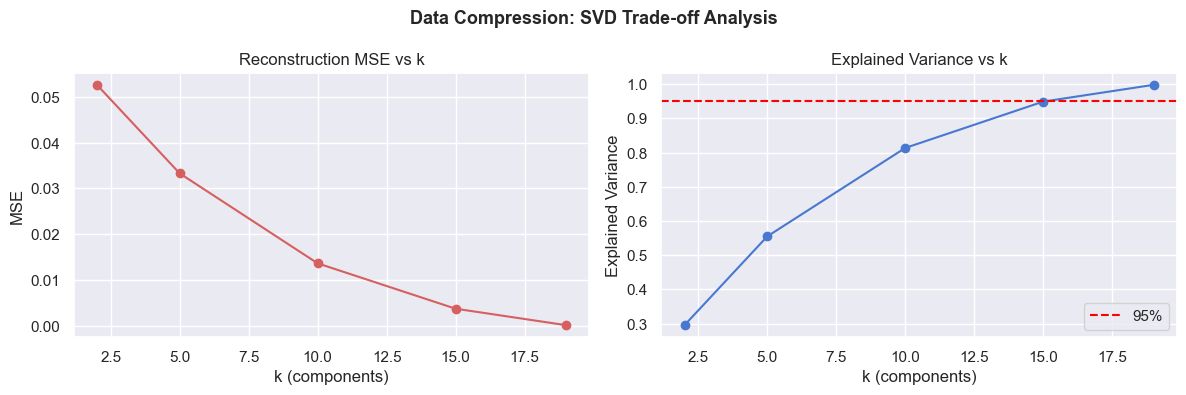

In [256]:
# Test different numbers of components with SVD
# See the trade-off between compression and reconstruction quality
X_g = genre_ohe[genre_feat_cols].values.astype(np.float32)
n_orig = X_g.shape[1]
results = []
for k in [2, 5, 10, 15, n_orig - 1]:
    sv = TruncatedSVD(n_components=k, random_state=42)
    compressed    = sv.fit_transform(X_g)
    reconstructed = sv.inverse_transform(compressed)
    mse = float(np.mean((X_g - reconstructed) ** 2))
    var = float(sv.explained_variance_ratio_.sum())
    results.append({'k': k, 'MSE': round(mse,5), 'Explained Var': round(var,4),
                    'Ratio': f'{k}/{n_orig}'})

comp_df = pd.DataFrame(results)
print('SVD Compression Results:')
display(comp_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(comp_df['k'], comp_df['MSE'], 'ro-')
axes[0].set_title('Reconstruction MSE vs k'); axes[0].set_xlabel('k (components)')
axes[0].set_ylabel('MSE')
axes[1].plot(comp_df['k'], comp_df['Explained Var'], 'bo-')
axes[1].axhline(0.95, color='red', ls='--', label='95%')
axes[1].set_title('Explained Variance vs k'); axes[1].set_xlabel('k (components)')
axes[1].set_ylabel('Explained Variance'); axes[1].legend()
plt.suptitle('Data Compression: SVD Trade-off Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/09_svd_compression_tradeoff.png', dpi=300, bbox_inches='tight')
plt.show()

---
## Section 10  Regression Analysis

**Regression** models the relationship between a numeric target and one or more features. We predict a movie's average rating using three model variants:

1. **Simple Linear Regression**  one predictor: `log(num_ratings)`
2. **Multiple Regression**  several predictors (log ratings, year, top genres)
3. **Log-Linear Model**  continuous predictors are log-transformed before fitting; captures multiplicative relationships

Models are compared on RA= (goodness of fit) and MSE(multiple regression analysis) (prediction error).

In [257]:
# Prepare regression dataset
reg_df = movie_features[movie_features['num_ratings'] >= 5].copy()
reg_df['log_num_ratings'] = np.log1p(reg_df['num_ratings'])
yr_min = reg_df['year'].min(); yr_max = reg_df['year'].max()
reg_df['year_norm'] = (reg_df['year'] - yr_min) / (yr_max - yr_min)
print(f'Regression dataset: {len(reg_df):,} movies')
print(reg_df[['num_ratings','avg_rating','year']].describe().round(2).to_string())

Regression dataset: 7,662 movies
       num_ratings  avg_rating     year
count      7662.00     7662.00  7662.00
mean         63.05        3.34  1994.89
std         127.84        0.56    17.90
min           5.00        0.56  1902.00
25%           9.00        3.00  1988.00
50%          19.00        3.42  1999.00
75%          56.00        3.75  2007.00
max        1701.00        4.79  2019.00


Simple Linear Regression
  Feature     : log_num_ratings
  Coefficient : 0.0847
  Intercept   : 3.0660
  R²          : 0.0439
  MSE         : 0.3006
  Equation    : avg_rating = 3.066 + 0.085 * log(num_ratings+1)


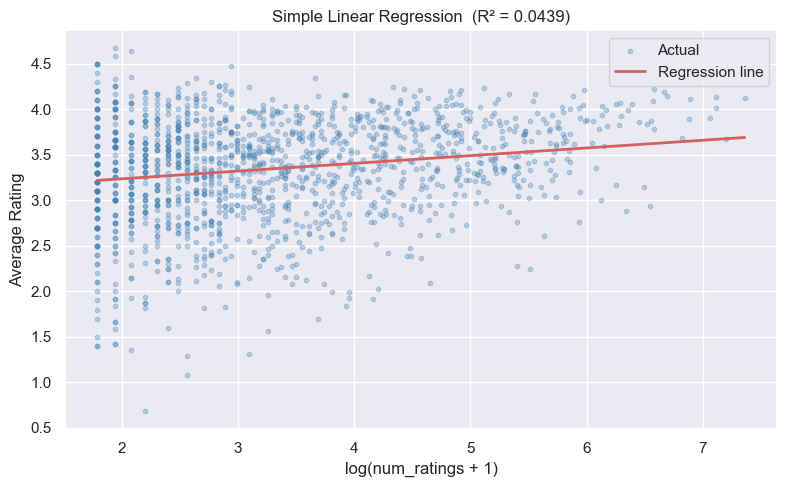

In [258]:
# 10.1 Simple Linear Regression
# Try to predict a movie's rating using just the number of ratings
# Check if popular movies tend to have higher average ratings
X_lr = reg_df[['log_num_ratings']].values
y_lr = reg_df['avg_rating'].values
X_lr_tr, X_lr_te, y_lr_tr, y_lr_te = train_test_split(X_lr, y_lr, test_size=0.2, random_state=42)

slr = LinearRegression()
slr.fit(X_lr_tr, y_lr_tr)
y_slr_pred = slr.predict(X_lr_te)
slr_r2  = r2_score(y_lr_te, y_slr_pred)
slr_mse = mean_squared_error(y_lr_te, y_slr_pred)

print('Simple Linear Regression')
print(f'  Feature     : log_num_ratings')
print(f'  Coefficient : {slr.coef_[0]:.4f}')
print(f'  Intercept   : {slr.intercept_:.4f}')
print(f'  R²          : {slr_r2:.4f}')
print(f'  MSE         : {slr_mse:.4f}')
print(f'  Equation    : avg_rating = {slr.intercept_:.3f} + {slr.coef_[0]:.3f} * log(num_ratings+1)')

plt.figure(figsize=(8, 5))
plt.scatter(X_lr_te, y_lr_te, alpha=0.3, s=10, color='steelblue', label='Actual')
x_line = np.linspace(X_lr_te.min(), X_lr_te.max(), 200).reshape(-1, 1)
plt.plot(x_line, slr.predict(x_line), 'r-', lw=2, label='Regression line')
plt.xlabel('log(num_ratings + 1)'); plt.ylabel('Average Rating')
plt.title(f'Simple Linear Regression  (R² = {slr_r2:.4f})')
plt.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/10_regression_simple_linear.png', dpi=300, bbox_inches='tight')
plt.show()

In [259]:
# 10.2 Multiple Regression
# Use more features to improve the model: year and top genres
top5_genres = feat_scores.head(5).index.tolist()
reg_g = reg_df.merge(genre_ohe[['movieId'] + top5_genres], on='movieId', how='left').fillna(0)

multi_feats = ['log_num_ratings', 'year_norm'] + top5_genres
X_m = reg_g[multi_feats].values
y_m = reg_g['avg_rating'].values
X_m_tr, X_m_te, y_m_tr, y_m_te = train_test_split(X_m, y_m, test_size=0.2, random_state=42)

mlr = LinearRegression()
mlr.fit(X_m_tr, y_m_tr)
y_m_pred = mlr.predict(X_m_te)
mr_r2  = r2_score(y_m_te, y_m_pred)
mr_mse = mean_squared_error(y_m_te, y_m_pred)

print('Multiple Regression')
print(f'  Features : {multi_feats}')
print(f'  R²       : {mr_r2:.4f}')
print(f'  MSE      : {mr_mse:.4f}')
coef_df = pd.DataFrame({'feature': multi_feats, 'coeff': mlr.coef_})
coef_df = coef_df.assign(abs=coef_df['coeff'].abs()).sort_values('abs', ascending=False)
display(coef_df[['feature','coeff']].reset_index(drop=True))

Multiple Regression
  Features : ['log_num_ratings', 'year_norm', 'Drama', 'Comedy', 'Crime', 'Horror', 'War']
  R²       : 0.1730
  MSE      : 0.2600


,feature,coeff
0,year_norm,-0.702902
1,Drama,0.279631
2,Horror,-0.215768
3,Comedy,-0.121298
4,log_num_ratings,0.086374
5,War,0.062745
6,Crime,0.020179


In [260]:
# 10.3 Log-Linear Model
# Test if a multiplicative relationship works better than additive
# Apply log transforms to continuous variables and compare results
X_ll = X_m.copy()
# Log-transform the continuous columns (first two)
X_ll[:, :2] = np.log1p(np.abs(X_m[:, :2]))
X_ll_tr, X_ll_te, y_ll_tr, y_ll_te = train_test_split(X_ll, y_m, test_size=0.2, random_state=42)

llr = LinearRegression()
llr.fit(X_ll_tr, y_ll_tr)
y_ll_pred = llr.predict(X_ll_te)
ll_r2  = r2_score(y_ll_te, y_ll_pred)
ll_mse = mean_squared_error(y_ll_te, y_ll_pred)

print('Log-Linear Model')
print(f'  Continuous features log-transformed: {multi_feats[:2]}')
print(f'  R²      : {ll_r2:.4f}')
print(f'  MSE : {ll_mse:.4f}')
print()

# Compare all three models
comparison = pd.DataFrame([
    {'Model': 'Simple Linear Regression', 'R2': round(slr_r2,4), 'MSE': round(slr_mse,4), 'Features': 1},
    {'Model': 'Multiple Regression',       'R2': round(mr_r2, 4), 'MSE': round(mr_mse, 4), 'Features': len(multi_feats)},
    {'Model': 'Log-Linear Model',          'R2': round(ll_r2, 4), 'MSE': round(ll_mse, 4), 'Features': len(multi_feats)},
])
print('Model Comparison:')
display(comparison)

Log-Linear Model
  Continuous features log-transformed: ['log_num_ratings', 'year_norm']
  R²      : 0.1740
  MSE : 0.2597

Model Comparison:


,Model,R2,MSE,Features
0,Simple Linear Regression,0.0439,0.3006,1
1,Multiple Regression,0.1730,0.2600,7
2,Log-Linear Model,0.1740,0.2597,7


---
## Section 11 Clustering (K-Means)

**Clustering** groups similar items together without using labels. **K-Means** partitions movies into *k* clusters by minimising the total within-cluster sum of squared distances to each centroid.

- The **Elbow Method** plots inertia (within-cluster SSE) vs *k* to suggest the optimal number of clusters
- Clusters are visualised in 2D using the PCA projection from Section 7

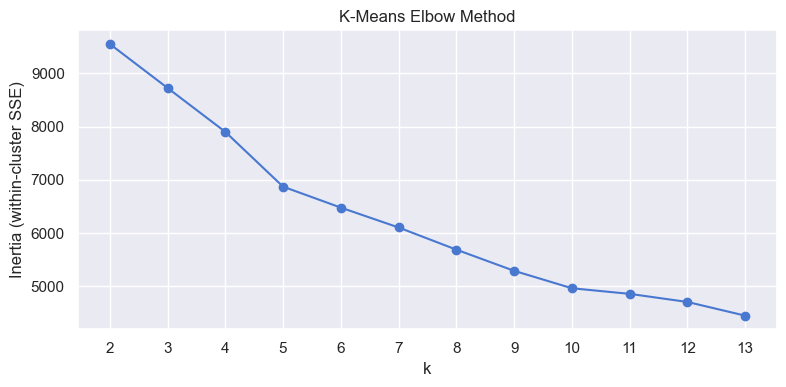

In [261]:
# Elbow Method - find the best number of clusters
# Sample 8k movies for speed (testing many k values takes time)
N_CLUST_SAMPLE = min(8_000, len(X_genres))
rng = np.random.RandomState(42)
s_idx = rng.choice(len(X_genres), N_CLUST_SAMPLE, replace=False)
X_cl  = X_genres[s_idx].astype(np.float32)

inertias = []
K_RANGE  = range(2, 14)
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=5, max_iter=100)
    km.fit(X_cl)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_RANGE, inertias, 'bo-')
plt.title('K-Means Elbow Method')
plt.xlabel('k')
plt.ylabel('Inertia (within-cluster SSE)')
plt.xticks(list(K_RANGE))
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/11_kmeans_elbow_method.png', dpi=300, bbox_inches='tight')
plt.show()

Cluster Centroids Top 3 Genres
  Cluster 0: Drama | Comedy | Romance                       (2,452 movies)
  Cluster 1: Comedy | Romance | Action                      (1,302 movies)
  Cluster 2: Unknown | Drama | Horror                       (679 movies)
  Cluster 3: Animation | Children | Adventure               (676 movies)
  Cluster 4: Documentary | Drama | Comedy                   (727 movies)
  Cluster 5: Thriller | Drama | Horror                      (834 movies)
  Cluster 6: Horror | Comedy | Sci_Fi                       (489 movies)
  Cluster 7: Action | Drama | Thriller                      (841 movies)


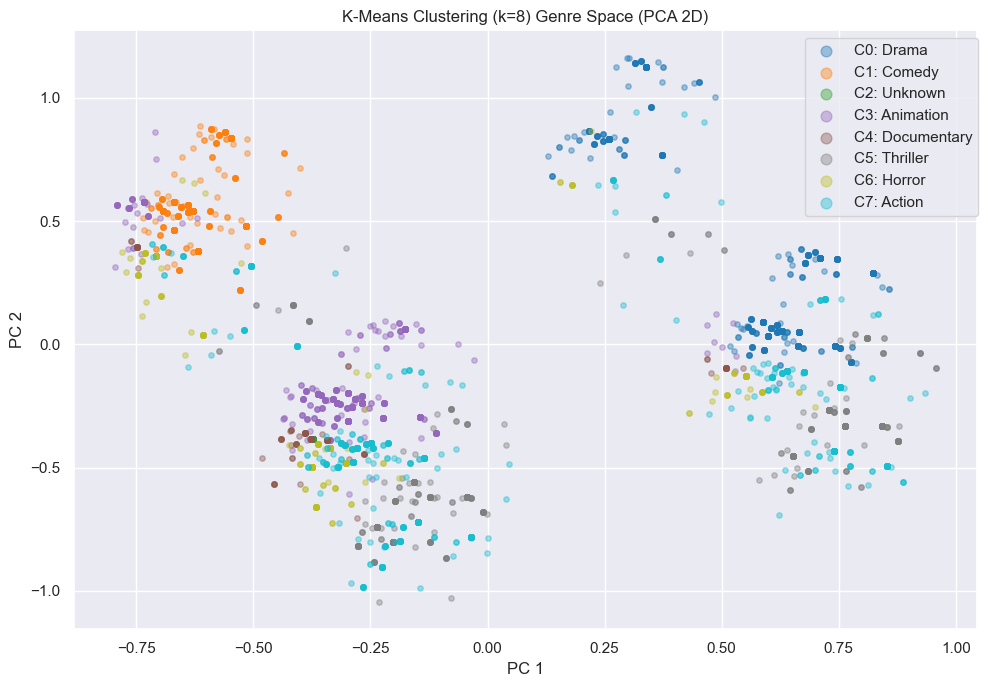

In [262]:
# Run K-Means with k=8 (good elbow point)
# Group movies by similar genres
K_BEST = 8
kmeans = KMeans(n_clusters=K_BEST, random_state=42, n_init=10, max_iter=300)
cl_labels = kmeans.fit_predict(X_cl)

cl_movies = movies_clean.iloc[s_idx].copy()
cl_movies['cluster'] = cl_labels

# Print the top genres for each cluster
centroids = pd.DataFrame(kmeans.cluster_centers_, columns=genre_feat_cols)
print('Cluster Centroids Top 3 Genres')
for i, row in centroids.iterrows():
    top3  = row.sort_values(ascending=False).head(3).index.tolist()
    count = int((cl_labels == i).sum())
    print(f'  Cluster {i}: {" | ".join(top3):<45}  ({count:,} movies)')

# Visualize clusters using PCA to reduce to 2D
pca2v = PCA(n_components=2, random_state=42)
X_2d  = pca2v.fit_transform(X_cl)

plt.figure(figsize=(10, 7))
colors = plt.cm.tab10(np.linspace(0, 1, K_BEST))
for i in range(K_BEST):
    m   = cl_labels == i
    top = centroids.iloc[i].sort_values(ascending=False).index[0]
    plt.scatter(X_2d[m, 0], X_2d[m, 1], c=[colors[i]],
                label=f'C{i}: {top}', alpha=0.4, s=15)
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.title(f'K-Means Clustering (k={K_BEST}) Genre Space (PCA 2D)')
plt.legend(markerscale=2, bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/11_kmeans_clustering_2d.png', dpi=300, bbox_inches='tight')
plt.show()

---
## Section 12 Content-Based Filtering

Recommends movies with similar genre profiles to the query movie.
**TF-IDF** weights each genre token by its discriminating power across the catalogue. **Cosine similarity** measures how aligned two genre vectors are.

In [263]:
# Content-Based Filtering
# Use TF-IDF to weight genres, find similar movies using cosine similarity

# Prepare genre strings for TF-IDF
movies_clean['genre_str'] = (
    movies_clean['genres']
    .str.replace('|', ' ', regex=False)
    .str.replace('Unknown', '', regex=False)
    .str.strip().fillna('')
)

# Filter ratings to only movies we have
valid_ids        = set(movies_clean['movieId'])
ratings_filtered = ratings_clean[ratings_clean['movieId'].isin(valid_ids)].copy()
movie_stats = (
    ratings_filtered.groupby('movieId')
    .agg(num_ratings=('rating','count'), avg_rating=('rating','mean'))
    .reset_index()
)

# Create lookup tables for fast movie ID/title lookups
movie_title_to_id = pd.Series(movies_clean['movieId'].values, index=movies_clean['title']).to_dict()
movie_id_to_idx   = pd.Series(movies_clean.index,             index=movies_clean['movieId']).to_dict()

tfidf        = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(movies_clean['genre_str'])
print(f'TF-IDF matrix : {tfidf_matrix.shape[0]:,} movies x {tfidf_matrix.shape[1]} genre terms')
print(f'Vocabulary    : {sorted(tfidf.vocabulary_.keys())}')

def _fuzzy_match(query):
    # Find a close match if the exact title isn't found
    if query in movie_title_to_id: return query
    hits = difflib.get_close_matches(query, list(movie_title_to_id), n=1, cutoff=0.35)
    if not hits: raise ValueError(f"No match for '{query}'.")
    print(f"  -> matched '{query}' to '{hits[0]}'")
    return hits[0]

def get_content_recommendations(title, n=10, min_ratings=50):
    # Find similar movies based on genre profiles
    title = _fuzzy_match(title)
    idx   = movie_id_to_idx[movie_title_to_id[title]]
    sims  = cosine_similarity(tfidf_matrix[idx], tfidf_matrix).flatten()
    sims[idx] = -1.0
    top   = np.argsort(-sims)
    res   = (movies_clean.iloc[top][['movieId','title','genres']].copy()
             .merge(movie_stats[['movieId','num_ratings','avg_rating']], on='movieId', how='left'))
    res['content_score'] = np.round(sims[top], 4)
    res = res[res['num_ratings'].fillna(0) >= min_ratings].head(n)
    res['avg_rating'] = res['avg_rating'].round(2)
    return res.reset_index(drop=True)

print('Content-Based Recommendations Toy Story (1995)')
print('Showing movies with similar genres that have at least 50 ratings in our sample:')
display(get_content_recommendations('Toy Story (1995)', n=10))

TF-IDF matrix : 62,423 movies x 21 genre terms
Vocabulary    : ['action', 'adventure', 'animation', 'children', 'comedy', 'crime', 'documentary', 'drama', 'fantasy', 'fi', 'film', 'horror', 'imax', 'musical', 'mystery', 'noir', 'romance', 'sci', 'thriller', 'war', 'western']
Content-Based Recommendations Toy Story (1995)
Showing movies with similar genres that have at least 50 ratings in our sample:


,movieId,title,genres,num_ratings,avg_rating,content_score
0,2294,Antz (1998),Adventure|Animation|Children|Comedy|Fantasy,220.0,3.36,1.0000
1,53121,Shrek the Third (2007),Adventure|Animation|Children|Comedy|Fantasy,88.0,2.90,1.0000
2,4016,"Emperor's New Groove, The (2000)",Adventure|Animation|Children|Comedy|Fantasy,167.0,3.62,1.0000
3,166461,Moana (2016),Adventure|Animation|Children|Comedy|Fantasy,87.0,3.82,1.0000
4,4886,"Monsters, Inc. (2001)",Adventure|Animation|Children|Comedy|Fantasy,680.0,3.87,1.0000
5,3114,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy,532.0,3.83,1.0000
6,134853,Inside Out (2015),Adventure|Animation|Children|Comedy|Drama|Fantasy,276.0,3.89,0.9751
7,65261,Ponyo (Gake no ue no Ponyo) (2008),Adventure|Animation|Children|Fantasy,52.0,3.88,0.9607
8,2116,"Lord of the Rings, The (1978)",Adventure|Animation|Children|Fantasy,104.0,3.23,0.9607
9,4366,Atlantis: The Lost Empire (2001),Adventure|Animation|Children|Fantasy,74.0,3.32,0.9607


---
## Section 13 Collaborative Filtering (SVD)

Recommends movies based on **patterns in user ratings** rather than content metadata. A sparse userÃ—movie matrix is decomposed via **Truncated SVD** (as in Section 9) to extract latent factors representing abstract user preferences and movie characteristics.

In [264]:
# Collaborative Filtering with SVD
# Use user rating patterns (not genres) to find similar movies
# Build a user-movie matrix with ratings

# Use top users and movies to keep the matrix smaller
TOP_U = 2_000; TOP_M = 3_000
top_u = ratings_filtered['userId'].value_counts().head(TOP_U).index
top_m = ratings_filtered['movieId'].value_counts().head(TOP_M).index
cf    = ratings_filtered[ratings_filtered['userId'].isin(top_u) &
                          ratings_filtered['movieId'].isin(top_m)].copy()

# Convert user/movie IDs to matrix indices
cf_users  = sorted(cf['userId'].unique())
cf_movies = sorted(cf['movieId'].unique())
u2i = {u:i for i,u in enumerate(cf_users)}
m2i = {m:i for i,m in enumerate(cf_movies)}
i2m = {i:m for m,i in m2i.items()}

rows = cf['userId'].map(u2i).values
cols = cf['movieId'].map(m2i).values
vals = cf['rating'].astype(np.float32).values
ui   = csr_matrix((vals,(rows,cols)), shape=(len(cf_users),len(cf_movies)))
spar = 1.0 - ui.nnz / (ui.shape[0]*ui.shape[1])
print(f'User-item matrix : {ui.shape[0]:,} x {ui.shape[1]:,}  |  sparsity: {spar:.2%}')

# Decompose the matrix using SVD to find latent factors
svd_cf = TruncatedSVD(n_components=50, random_state=42)
mf     = svd_cf.fit_transform(ui.T)   # shape: (n_movies, 50)
print(f'SVD explained variance (50 components): {svd_cf.explained_variance_ratio_.sum():.4f}')

def get_collab_recommendations(title, n=10):
    # Find similar movies based on user rating patterns
    title = _fuzzy_match(title)
    mid   = movie_title_to_id[title]
    if mid not in m2i:
        raise ValueError(f"'{title}' not in CF subset. Try content-based.")
    ci    = m2i[mid]
    sims  = cosine_similarity(mf[ci:ci+1], mf).flatten()
    sims[ci] = -1.0
    top   = np.argsort(-sims)[:n]
    ids   = [i2m[i] for i in top]
    sm    = {ids[k]: round(float(sims[top[k]]),4) for k in range(len(ids))}
    res   = (movies_clean[movies_clean['movieId'].isin(ids)][['movieId','title','genres']].copy()
             .merge(movie_stats[['movieId','num_ratings','avg_rating']], on='movieId', how='left'))
    res['collab_score'] = res['movieId'].map(sm)
    res['avg_rating']   = res['avg_rating'].round(2)
    return res.sort_values('collab_score', ascending=False).reset_index(drop=True)

print('Collaborative Recommendations -- Toy Story (1995)')
print('Showing movies with similar user rating patterns (based on SVD latent factors):')
display(get_collab_recommendations('Toy Story (1995)', n=10))

User-item matrix : 2,000 x 3,000  |  sparsity: 93.65%
SVD explained variance (50 components): 0.4434
Collaborative Recommendations -- Toy Story (1995)
Showing movies with similar user rating patterns (based on SVD latent factors):


,movieId,title,genres,num_ratings,avg_rating,collab_score
0,3114,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy,532,3.83,0.8488
1,1270,Back to the Future (1985),Adventure|Comedy|Sci-Fi,1023,3.97,0.8161
2,2355,"Bug's Life, A (1998)",Adventure|Animation|Children|Comedy,483,3.57,0.8108
3,1265,Groundhog Day (1993),Comedy|Fantasy|Romance,764,3.91,0.8102
4,364,"Lion King, The (1994)",Adventure|Animation|Children|Drama|Musical|IMAX,888,3.84,0.8094
5,480,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller,1333,3.67,0.7988
6,588,Aladdin (1992),Adventure|Animation|Children|Comedy|Musical,915,3.68,0.7977
7,356,Forrest Gump (1994),Comedy|Drama|Romance|War,1694,4.02,0.7897
8,1580,Men in Black (a.k.a. MIB) (1997),Action|Comedy|Sci-Fi,806,3.63,0.7891
9,260,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi,1431,4.11,0.7829


---
## Section 14 Hybrid Recommender

Blends content-based and collaborative scores using **Min-Max Normalization** so both are on the same [0, 1] scale before the weighted average:

```
hybrid = alpha * content_score + (1 - alpha) * collab_score
```

In [265]:
def get_hybrid_recommendations(title, n=10, alpha=0.6):
    # Combine content-based and collaborative filtering
    # Alpha = 0.6 means 60% content-based, 40% collaborative
    title  = _fuzzy_match(title)
    mid    = movie_title_to_id[title]
    cb_idx = movie_id_to_idx[mid]

    # Calculate content-based similarity scores
    cb_sim = cosine_similarity(tfidf_matrix[cb_idx], tfidf_matrix).flatten()
    cb_sim[cb_idx] = 0.0

    # Calculate collaborative filtering scores
    cf_sim = np.zeros(len(movies_clean), dtype=np.float32)
    if mid in m2i:
        ci       = m2i[mid]
        cf_raw   = cosine_similarity(mf[ci:ci+1], mf).flatten()
        cf_raw[ci] = 0.0
        for j, sc in enumerate(cf_raw):
            aidx = movie_id_to_idx.get(i2m[j])
            if aidx is not None: cf_sim[aidx] = float(sc)

    # Normalize both scores to [0, 1] for comparison
    sc = MinMaxScaler()
    cb = sc.fit_transform(cb_sim.reshape(-1,1)).flatten()
    cf = sc.fit_transform(cf_sim.reshape(-1,1)).flatten()
    
    # Blend them together
    h  = alpha * cb + (1-alpha) * cf
    h[cb_idx] = -1.0
    ti = np.argsort(-h)
    res = (movies_clean.iloc[ti][['movieId','title','genres']].copy()
           .merge(movie_stats[['movieId','num_ratings','avg_rating']], on='movieId', how='left'))
    res['hybrid_score'] = np.round(h[ti], 4)
    res = res[res['num_ratings'].fillna(0) >= 50].head(n)
    res['avg_rating'] = res['avg_rating'].round(2)
    return res.reset_index(drop=True)

print('Hybrid Recommendations -- Toy Story (1995)  (alpha=0.6)')
print('=' * 60)
display(get_hybrid_recommendations('Toy Story (1995)', n=10, alpha=0.6))

print()
print('Hybrid Recommendations -- The Dark Knight   (alpha=0.5)')
print('Showing movies similar in both genre and user rating patterns (equal weight):')
display(get_hybrid_recommendations('The Dark Knight', n=10, alpha=0.5))

Hybrid Recommendations -- Toy Story (1995)  (alpha=0.6)


,movieId,title,genres,num_ratings,avg_rating,hybrid_score
0,3114,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy,532.0,3.83,1.0000
1,4886,"Monsters, Inc. (2001)",Adventure|Animation|Children|Comedy|Fantasy,680.0,3.87,0.9543
2,2294,Antz (1998),Adventure|Animation|Children|Comedy|Fantasy,220.0,3.36,0.9386
3,4306,Shrek (2001),Adventure|Animation|Children|Comedy|Fantasy|Ro...,906.0,3.76,0.9297
4,2355,"Bug's Life, A (1998)",Adventure|Animation|Children|Comedy,483.0,3.57,0.9029
5,4016,"Emperor's New Groove, The (2000)",Adventure|Animation|Children|Comedy|Fantasy,167.0,3.62,0.8799
6,6377,Finding Nemo (2003),Adventure|Animation|Children|Comedy,703.0,3.81,0.8604
7,2987,Who Framed Roger Rabbit? (1988),Adventure|Animation|Children|Comedy|Crime|Fant...,466.0,3.59,0.8433
8,673,Space Jam (1996),Adventure|Animation|Children|Comedy|Fantasy|Sc...,205.0,2.87,0.8271
9,2,Jumanji (1995),Adventure|Children|Fantasy,475.0,3.31,0.8143



Hybrid Recommendations -- The Dark Knight   (alpha=0.5)
Showing movies similar in both genre and user rating patterns (equal weight):
  -> matched 'The Dark Knight' to 'The Dark Knight (2011)'


,movieId,title,genres,num_ratings,avg_rating,hybrid_score
0,37733,"History of Violence, A (2005)",Action|Crime|Drama|Thriller,102.0,3.66,0.5
1,3256,Patriot Games (1992),Action|Crime|Drama|Thriller,190.0,3.71,0.5
2,3275,"Boondock Saints, The (2000)",Action|Crime|Drama|Thriller,194.0,3.98,0.5
3,3265,Hard-Boiled (Lat sau san taam) (1992),Action|Crime|Drama|Thriller,52.0,3.83,0.5
4,4901,Spy Game (2001),Action|Crime|Drama|Thriller,112.0,3.60,0.5
5,996,Last Man Standing (1996),Action|Crime|Drama|Thriller,62.0,2.95,0.5
6,8798,Collateral (2004),Action|Crime|Drama|Thriller,215.0,3.76,0.5
7,46335,"Fast and the Furious: Tokyo Drift, The (Fast a...",Action|Crime|Drama|Thriller,52.0,2.68,0.5
8,2959,Fight Club (1999),Action|Crime|Drama|Thriller,1212.0,4.21,0.5
9,59369,Taken (2008),Action|Crime|Drama|Thriller,237.0,3.69,0.5


---
## Section 15 Decision Tree Classification

**Example** predict whether a user will *like* a movie defined as rating it **4.0**.

Features used:
- `avg_movie_rating` / `num_movie_ratings` movie-level stats (from Data Integration)
- `avg_user_rating` / `num_user_ratings` user-level stats
- One-hot genre columns selected via Attribute Subset Selection 

The rating discretization from section 6 defines the class boundary.

In [266]:
# Decision Tree Classification
# Predict if someone will like a movie (rating >= 4.0)
# Use movie stats, user stats, and genres as features

dt_r = ratings_filtered.copy()
dt_r['liked'] = (dt_r['rating'] >= 4.0).astype(np.int8)

# Calculate movie and user statistics
m_agg = (ratings_filtered.groupby('movieId')
         .agg(avg_movie_rating=('rating','mean'), num_movie_ratings=('rating','count'))
         .reset_index())
u_agg = (ratings_filtered.groupby('userId')
         .agg(avg_user_rating=('rating','mean'), num_user_ratings=('rating','count'))
         .reset_index())

# Merge everything together
dt_full = (dt_r
           .merge(m_agg,     on='movieId', how='left')
           .merge(u_agg,     on='userId',  how='left')
           .merge(genre_ohe, on='movieId', how='left'))

feat_cols = ['avg_movie_rating','num_movie_ratings',
             'avg_user_rating', 'num_user_ratings'] + genre_feat_cols
dt_clean = dt_full[feat_cols + ['liked']].dropna().copy()

print(f'Feature matrix : {dt_clean.shape[0]:,} rows x {len(feat_cols)} features')
print('Class balance  :')
print(dt_clean['liked'].value_counts().rename({0:'Not Liked',1:'Liked'}).to_string())

# Split into train/test
X = dt_clean[feat_cols]; y = dt_clean['liked']
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train : {len(Xtr):,}   Test : {len(Xte):,}')

# Train decision tree
clf    = DecisionTreeClassifier(max_depth=6, min_samples_leaf=20, random_state=42)
clf.fit(Xtr, ytr)
ypred  = clf.predict(Xte)
acc    = accuracy_score(yte, ypred)

print(f'\nTest Accuracy : {acc:.4f}\n')
print(classification_report(yte, ypred, target_names=['Not Liked','Liked']))

Feature matrix : 500,000 rows x 24 features
Class balance  :
liked
Liked        252544
Not Liked    247456
Train : 400,000   Test : 100,000

Test Accuracy : 0.7183

              precision    recall  f1-score   support

   Not Liked       0.73      0.69      0.71     49491
       Liked       0.71      0.75      0.73     50509

    accuracy                           0.72    100000
   macro avg       0.72      0.72      0.72    100000
weighted avg       0.72      0.72      0.72    100000



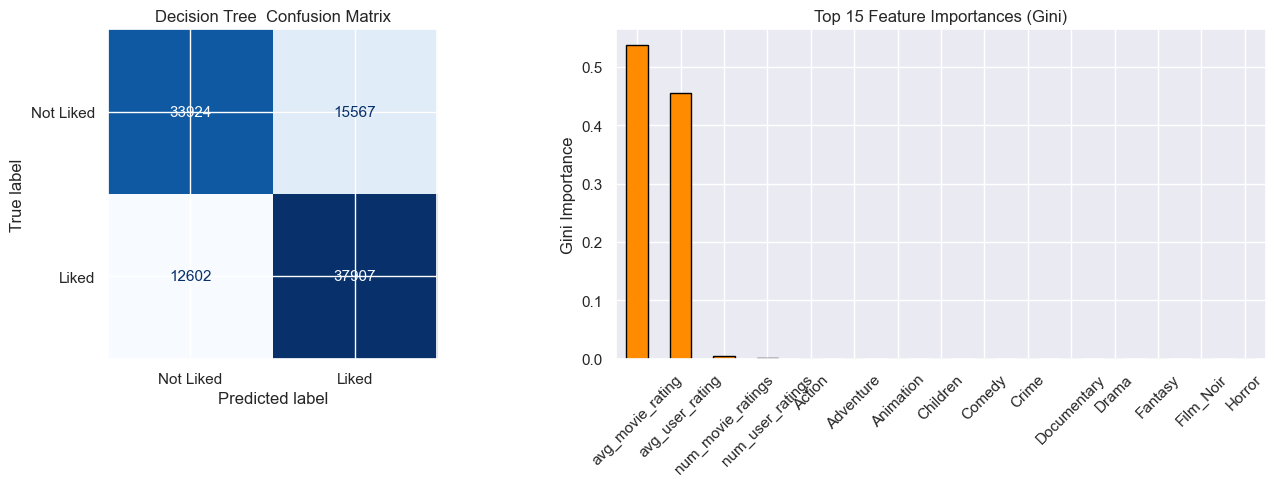

Top-level Decision Tree Rules (depth <= 3):
|--- avg_movie_rating <= 3.55
|   |--- avg_user_rating <= 3.74
|   |   |--- avg_movie_rating <= 3.12
|   |   |   |--- avg_user_rating <= 3.39
|   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- avg_user_rating >  3.39
|   |   |   |   |--- truncated branch of depth 3
|   |   |--- avg_movie_rating >  3.12
|   |   |   |--- avg_user_rating <= 3.26
|   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- avg_user_rating >  3.26
|   |   |   |   |--- truncated branch of depth 3
|   |--- avg_user_rating >  3.74
|   |   |--- avg_user_rating <= 4.10
|   |   |   |--- avg_movie_rating <= 3.09
|   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- avg_movie_rating >  3.09
|   |   |   |   |--- truncated branch of depth 3
|   |   |--- avg_user_rating >  4.10
|   |   |   |--- avg_movie_rating <= 3.02
|   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- avg_movie_rating >  3.02
|   |   |   |   |--- truncated bran

In [267]:
# Display confusion matrix and feature importance
cm   = confusion_matrix(yte, ypred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Liked','Liked'])
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Decision Tree  Confusion Matrix', fontsize=12)

# Find which features were most important
imps = pd.Series(clf.feature_importances_, index=feat_cols).sort_values(ascending=False).head(15)
imps.plot(kind='bar', ax=axes[1], color='darkorange', edgecolor='black')
axes[1].set_title('Top 15 Feature Importances (Gini)', fontsize=12)
axes[1].set_ylabel('Gini Importance')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/15_decision_tree_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print('Top-level Decision Tree Rules (depth <= 3):')
print(export_text(clf, feature_names=feat_cols, max_depth=3))

---
## Section 16 Export Results

Save all outputs to `my_results.xlsx` with one sheet per analysis type.

In [268]:
# Save all results to Excel
DEMO  = 'Toy Story (1995)'
XFILE = f'{OUTPUT_DIR}/my_results.xlsx'

# Generate recommendations using all three methods
cb_recs  = get_content_recommendations(DEMO, n=10)
cf_recs  = get_collab_recommendations(DEMO,  n=10)
hyb_recs = get_hybrid_recommendations(DEMO,  n=10, alpha=0.6)

# Prepare classification results for export
cm_df = pd.DataFrame(cm,
    index=['True: Not Liked','True: Liked'],
    columns=['Pred: Not Liked','Pred: Liked'])
dt_sum = pd.DataFrame([{'accuracy':round(acc,4),'max_depth':6,
    'n_train':len(Xtr),'n_test':len(Xte),
    'n_liked':int(y.sum()),'n_not_liked':int((y==0).sum())}])

# Write all results to Excel
with pd.ExcelWriter(XFILE, engine='openpyxl') as w:
    cb_recs.to_excel( w, sheet_name='content_based',   index=False)
    cf_recs.to_excel( w, sheet_name='collaborative',   index=False)
    hyb_recs.to_excel(w, sheet_name='hybrid',          index=False)
    cm_df.to_excel(   w, sheet_name='decision_tree_cm'           )
    dt_sum.to_excel(  w, sheet_name='dt_summary',      index=False)
    comparison.to_excel(w, sheet_name='regression_summary', index=False)
    comp_df.to_excel( w, sheet_name='compression_analysis', index=False)

print(f"All results saved to '{XFILE}'")
print('Sheets: content_based | collaborative | hybrid | decision_tree_cm | dt_summary | regression_summary | compression_analysis')
print(f'\nAll output files are in the {OUTPUT_DIR}/ folder')

All results saved to 'output/my_results.xlsx'
Sheets: content_based | collaborative | hybrid | decision_tree_cm | dt_summary | regression_summary | compression_analysis

All output files are in the output/ folder
